# Delay Embeddings under Partial Observability

Encoders normally see a single snapshot `x_t`. Under partial observations,
delay coordinates can — under suitable conditions — reconstruct attractor
geometry from a measurement time series [@Takens1981]. Related Hankel delay
matrices are a standard tool for linear / Koopman models of chaotic dynamics
[@Brunton2017HAVOK] and for convergent DMD approximations of Koopman spectra on
ergodic systems [@Arbabi2017HankelDMD].

This notebook uses an **encoder-side analogue**: stack the last `n_delays`
observed node features into channels (not a full HAVOK or Hankel-DMD pipeline).
The goal is empirical — stabilize held-out multi-step forecasts under missing
sensors.

> **Primary question.** With sparse sensor inputs and supervision against
> full-state targets, does capacity-matched `n_delays = k` stabilize held-out
> multi-step forecasts relative to a zero-pad control?

**What to look for on Lorenz-96:** pad held-out RMSE rising sharply by $H=3$
(latent amplitude blow-up) vs roughly flat delay stacking. Absolute skill may
still sit above a climatology baseline — compare relative curves.


## Methodology

1. **Capacity match.** Shared `GNNEncoder(k_max · F, …)`. Delay arm stacks
   `k_max` snapshots; control uses a zero-pad wrapper with `n_delays=1`.
2. **Sparse inputs, full targets.** Held-out nodes are zeroed in the *input*
   sequence. A custom loop encodes sparse history, advances one step, and
   applies MSE vs the **fully observed** next state. (Library `fit` alone only
   supervises observed nodes, so it cannot teach held-out reconstruction.)
3. **Metrics.** Primary: held-out RMSE vs horizon. Secondary: full-state RMSE.
   A trajectory-mean climatology on held-out nodes is an in-sample baseline
   (slightly optimistic); use it for absolute skill, not as a proof floor.
4. **Scope.** Lorenz-96 is the decisive demo. IEEE 118 is a secondary stress
   check — a delay win is not required there.

CI uses a short epoch budget; interactive runs use a fuller demo budget.


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import os

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import torch
from torch import Tensor, nn
from torch_geometric.data import Data

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel, GraphSnapshotSequence
from koopman_graph.datasets import IEEE118DynamicBenchmark, Lorenz96GraphBenchmark
from koopman_graph.graph_utils import propagate_latent
from koopman_graph.metrics import masked_rmse, rmse

CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
EPOCHS = 8 if CI else 40
K_MAX = 5
HORIZONS = (1, 2, 3)
DROP_FRACTIONS = (0.25, 0.5) if CI else (0.25, 0.5, 0.65)
HIDDEN, LATENT = (16, 8) if CI else (32, 16)
_ = torch.manual_seed(0)


In [2]:
class ChannelPadEncoder(nn.Module):
    """Capacity-matched no-delay control: pad (N, F) → (N, k_max·F) with zeros."""

    def __init__(self, base_encoder: GNNEncoder, feature_dim: int, k_max: int) -> None:
        super().__init__()
        if base_encoder.in_channels != k_max * feature_dim:
            raise ValueError("base_encoder.in_channels must equal k_max * feature_dim")
        self.base_encoder = base_encoder
        self.feature_dim = feature_dim
        self.k_max = k_max
        self.in_channels = feature_dim
        self.latent_dim = base_encoder.latent_dim
        self.hidden_channels = base_encoder.hidden_channels
        self.num_layers = base_encoder.num_layers
        self.activation_name = base_encoder.activation_name

    def forward(
        self,
        x_or_data: Tensor | Data,
        edge_index: Tensor | None = None,
        edge_weight: Tensor | None = None,
    ) -> Tensor:
        if isinstance(x_or_data, Data):
            x = x_or_data.x
            edge_index = x_or_data.edge_index if edge_index is None else edge_index
            edge_weight = (
                getattr(x_or_data, "edge_weight", None)
                if edge_weight is None
                else edge_weight
            )
        else:
            x = x_or_data
            if edge_index is None:
                raise ValueError("edge_index required for tensor input")
        pad = x.new_zeros(x.size(0), self.k_max * self.feature_dim - self.feature_dim)
        return self.base_encoder(torch.cat([x, pad], dim=-1), edge_index, edge_weight)


def make_sparse_inputs(
    full: GraphSnapshotSequence,
    drop_fraction: float,
    *,
    seed: int,
) -> GraphSnapshotSequence:
    if not 0.0 <= drop_fraction < 1.0:
        raise ValueError(f"drop_fraction must be in [0, 1), got {drop_fraction}")
    g = torch.Generator().manual_seed(seed)
    keep = torch.rand(full.num_nodes, generator=g) >= drop_fraction
    if not bool(keep.any()):
        keep[0] = True
    if bool(keep.all()):
        keep[-1] = False
    masks = keep.unsqueeze(0).expand(full.num_timesteps, -1).contiguous()
    snapshots: list[Data] = []
    for t, snap in enumerate(full):
        x = snap.x.clone()
        x[~masks[t]] = 0.0
        payload = {"x": x, "edge_index": snap.edge_index.clone()}
        weight = getattr(snap, "edge_weight", None)
        if weight is not None:
            payload["edge_weight"] = weight.clone()
        snapshots.append(Data(**payload))
    return GraphSnapshotSequence(
        snapshots,
        observation_masks=masks,
        allow_dynamic_topology=full.allow_dynamic_topology,
    )


def build_capacity_matched(
    *,
    feature_dim: int,
    k_max: int,
    use_delays: bool,
    time_step: float,
    seed: int = 0,
) -> GraphKoopmanModel:
    torch.manual_seed(seed)
    base = GNNEncoder(k_max * feature_dim, HIDDEN, LATENT)
    decoder = GNNDecoder(LATENT, HIDDEN, feature_dim)
    if use_delays:
        encoder: nn.Module = base
        n_delays = k_max
    else:
        encoder = ChannelPadEncoder(base, feature_dim=feature_dim, k_max=k_max)
        n_delays = 1
    return GraphKoopmanModel(
        encoder=encoder,
        decoder=decoder,
        latent_dim=LATENT,
        time_step=time_step,
        n_delays=n_delays,
    )


def fit_sparse_to_full(
    model: GraphKoopmanModel,
    sparse_inputs: GraphSnapshotSequence,
    full_targets: GraphSnapshotSequence,
    *,
    epochs: int,
    lr: float = 1e-2,
) -> None:
    """Encode sparse history; supervise decode against full next-state targets."""
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.train()
    for _ in range(epochs):
        for t in range(sparse_inputs.num_timesteps - 1):
            z = model.encode_at(sparse_inputs, t)
            target_snap = full_targets[t + 1]
            z_next = propagate_latent(
                model.koopman,
                z,
                edge_index=target_snap.edge_index,
                edge_weight=getattr(target_snap, "edge_weight", None),
                default_delta_t=model.time_step,
            )
            pred = model.decoder(
                z_next,
                target_snap.edge_index,
                getattr(target_snap, "edge_weight", None),
            )
            loss = nn.functional.mse_loss(pred, target_snap.x)
            opt.zero_grad()
            loss.backward()
            opt.step()


def count_encoder_params(model: GraphKoopmanModel) -> int:
    return sum(p.numel() for p in model.encoder.parameters())


@torch.no_grad()
def evaluate_sparse_forecast(
    model: GraphKoopmanModel,
    sparse_inputs: GraphSnapshotSequence,
    full_targets: GraphSnapshotSequence,
    *,
    horizons: tuple[int, ...] = (1, 2, 3),
) -> dict:
    """Predict from sparse inputs; score vs full targets + in-sample climatology."""
    max_h = max(horizons)
    origins = list(range(0, sparse_inputs.num_timesteps - max_h))
    if not origins:
        raise ValueError("sequence too short for requested horizons")

    mean_state = torch.stack([snap.x for snap in full_targets], dim=0).mean(dim=0)
    sums = {h: {"held": 0.0, "full": 0.0, "mean": 0.0} for h in horizons}
    was_training = model.training
    model.eval()
    try:
        for start in origins:
            history = None
            if model.n_delays > 1:
                history = [
                    sparse_inputs[t]
                    for t in range(max(0, start - model.n_delays + 1), start)
                ]
            preds = model.predict(
                sparse_inputs[start],
                steps=max_h,
                history=history,
            )
            for h in horizons:
                pred = preds[h - 1].x
                target = full_targets[start + h].x
                held = ~sparse_inputs.observation_mask_at(start + h)
                sums[h]["held"] += float(masked_rmse(pred, target, held).cpu())
                sums[h]["full"] += float(rmse(pred, target).cpu())
                sums[h]["mean"] += float(
                    masked_rmse(mean_state.expand_as(pred), target, held).cpu()
                )
    finally:
        model.train(was_training)

    n = float(len(origins))
    held = [sums[h]["held"] / n for h in horizons]
    full = [sums[h]["full"] / n for h in horizons]
    mean_b = [sums[h]["mean"] / n for h in horizons]
    return {
        "horizons": list(horizons),
        "held_rmse": held,
        "full_rmse": full,
        "mean_held_rmse": mean_b,
        "aggregate_held_rmse": sum(held) / len(held),
        "aggregate_full_rmse": sum(full) / len(full),
        "h3_held_rmse": held[horizons.index(3)] if 3 in horizons else held[-1],
    }


## Synthetic Lorenz-96 (primary)

Drop 50% of sensors. Train sparse→full; plot held-out (and full-state) RMSE vs
horizon. The claim is that delay stacking stays flatter than the pad control —
not that either beats climatology.


In [3]:
l96 = Lorenz96GraphBenchmark.generate(
    num_nodes=8 if CI else 12,
    num_timesteps=36 if CI else 80,
    seed=3,
    forcing=8.0,
    burn_in=40 if CI else 100,
)
feature_dim = int(l96[0].x.size(-1))
l96_sparse = make_sparse_inputs(l96, drop_fraction=0.5, seed=3)
print(
    "Nodes observed/held-out:",
    int(l96_sparse.observation_mask_at(0).sum()),
    int((~l96_sparse.observation_mask_at(0)).sum()),
)

control = build_capacity_matched(
    feature_dim=feature_dim, k_max=K_MAX, use_delays=False, time_step=0.05
)
delayed = build_capacity_matched(
    feature_dim=feature_dim, k_max=K_MAX, use_delays=True, time_step=0.05
)
full_ref = build_capacity_matched(
    feature_dim=feature_dim, k_max=K_MAX, use_delays=False, time_step=0.05
)

assert count_encoder_params(control) == count_encoder_params(delayed)

fit_sparse_to_full(control, l96_sparse, l96, epochs=EPOCHS)
fit_sparse_to_full(delayed, l96_sparse, l96, epochs=EPOCHS)
# full-train reference: same loop but encode from fully observed inputs
fit_sparse_to_full(full_ref, l96, l96, epochs=EPOCHS)

eval_control = evaluate_sparse_forecast(control, l96_sparse, l96, horizons=HORIZONS)
eval_delay = evaluate_sparse_forecast(delayed, l96_sparse, l96, horizons=HORIZONS)
eval_full = evaluate_sparse_forecast(full_ref, l96_sparse, l96, horizons=HORIZONS)

print(f"Encoder params (matched): {count_encoder_params(delayed)}")
print(
    "Held-out RMSE by horizon | "
    f"pad={ [round(v, 3) for v in eval_control['held_rmse']] } | "
    f"delay={ [round(v, 3) for v in eval_delay['held_rmse']] } | "
    f"full→sparse={ [round(v, 3) for v in eval_full['held_rmse']] } | "
    f"mean={ [round(v, 3) for v in eval_control['mean_held_rmse']] }"
)
print(
    "H=3 held-out gap (pad − delay): "
    f"{eval_control['h3_held_rmse'] - eval_delay['h3_held_rmse']:+.4f}"
)


Nodes observed/held-out: 5 7
Encoder params (matched): 720
Held-out RMSE by horizon | pad=[5.541, 8.433, 14.536] | delay=[5.599, 5.593, 5.205] | full→sparse=[5.701, 6.324, 14.25] | mean=[3.722, 3.712, 3.704]
H=3 held-out gap (pad − delay): +9.3312


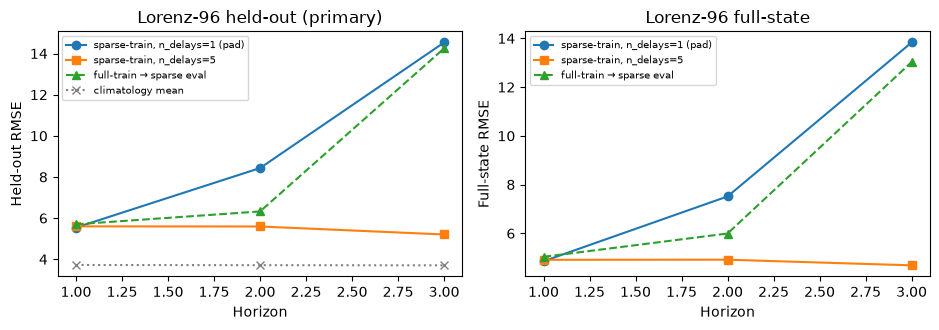

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharex=True)
for ax, key, ylabel, title in (
    (axes[0], "held_rmse", "Held-out RMSE", "Lorenz-96 held-out (primary)"),
    (axes[1], "full_rmse", "Full-state RMSE", "Lorenz-96 full-state"),
):
    ax.plot(
        eval_control["horizons"],
        eval_control[key],
        marker="o",
        label="sparse-train, n_delays=1 (pad)",
    )
    ax.plot(
        eval_delay["horizons"],
        eval_delay[key],
        marker="s",
        label=f"sparse-train, n_delays={K_MAX}",
    )
    ax.plot(
        eval_full["horizons"],
        eval_full[key],
        marker="^",
        linestyle="--",
        label="full-train → sparse eval",
    )
    if key == "held_rmse":
        ax.plot(
            eval_control["horizons"],
            eval_control["mean_held_rmse"],
            marker="x",
            linestyle=":",
            color="gray",
            label="climatology mean",
        )
    ax.set_xlabel("Horizon")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


### Drop-fraction stress check ($H=3$)

Refit at a few drop rates and compare $H=3$ held-out RMSE. This is **not** a
monotone sparsity theorem: moderate drop often favors delays; very high drop
can flip the blow-up onto the delay arm. Gaps are seed- and budget-sensitive.


drop=0.25 | H3 pad=5.551 | delay=4.648 | gap=+0.903 | mean=3.789
drop=0.50 | H3 pad=14.536 | delay=5.205 | gap=+9.331 | mean=3.704
drop=0.65 | H3 pad=7.437 | delay=15.791 | gap=-8.354 | mean=3.693


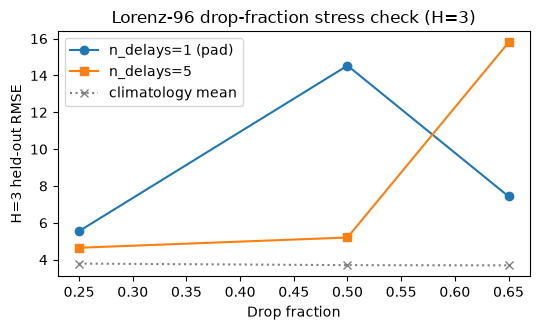

In [5]:
sweep_pad, sweep_delay, sweep_mean = [], [], []
for drop in DROP_FRACTIONS:
    sparse = make_sparse_inputs(l96, drop_fraction=drop, seed=3)
    m_pad = build_capacity_matched(
        feature_dim=feature_dim, k_max=K_MAX, use_delays=False, time_step=0.05
    )
    m_del = build_capacity_matched(
        feature_dim=feature_dim, k_max=K_MAX, use_delays=True, time_step=0.05
    )
    fit_sparse_to_full(m_pad, sparse, l96, epochs=EPOCHS)
    fit_sparse_to_full(m_del, sparse, l96, epochs=EPOCHS)
    s_pad = evaluate_sparse_forecast(m_pad, sparse, l96, horizons=HORIZONS)
    s_del = evaluate_sparse_forecast(m_del, sparse, l96, horizons=HORIZONS)
    sweep_pad.append(s_pad["h3_held_rmse"])
    sweep_delay.append(s_del["h3_held_rmse"])
    sweep_mean.append(s_pad["mean_held_rmse"][-1])
    print(
        f"drop={drop:.2f} | H3 pad={s_pad['h3_held_rmse']:.3f} | "
        f"delay={s_del['h3_held_rmse']:.3f} | "
        f"gap={s_pad['h3_held_rmse'] - s_del['h3_held_rmse']:+.3f} | "
        f"mean={s_pad['mean_held_rmse'][-1]:.3f}"
    )

fig, ax = plt.subplots(figsize=(5.5, 3.4))
drops = list(DROP_FRACTIONS)
ax.plot(drops, sweep_pad, marker="o", label="n_delays=1 (pad)")
ax.plot(drops, sweep_delay, marker="s", label=f"n_delays={K_MAX}")
ax.plot(drops, sweep_mean, marker="x", linestyle=":", color="gray", label="climatology mean")
ax.set_xlabel("Drop fraction")
ax.set_ylabel("H=3 held-out RMSE")
ax.set_title("Lorenz-96 drop-fraction stress check (H=3)")
ax.legend()
fig.tight_layout()
plt.show()


## IEEE 118-bus (secondary)

Same protocol, for inspection only. Curves can be non-monotonic; a decreasing
`full-train → sparse eval` line usually reflects under-amplitude drift, not
improving multi-step skill. A delay win is not required for the notebook claim.


In [6]:
ieee = IEEE118DynamicBenchmark.generate(
    num_timesteps=28 if CI else 60,
    seed=11,
)
f_ieee = int(ieee[0].x.size(-1))
ieee_sparse = make_sparse_inputs(ieee, drop_fraction=0.5, seed=11)
k_ieee = 3
ieee_h = (1, 2) if CI else HORIZONS

ieee_control = build_capacity_matched(
    feature_dim=f_ieee, k_max=k_ieee, use_delays=False, time_step=1.0
)
ieee_delay = build_capacity_matched(
    feature_dim=f_ieee, k_max=k_ieee, use_delays=True, time_step=1.0
)
ieee_full = build_capacity_matched(
    feature_dim=f_ieee, k_max=k_ieee, use_delays=False, time_step=1.0
)

fit_sparse_to_full(ieee_control, ieee_sparse, ieee, epochs=EPOCHS)
fit_sparse_to_full(ieee_delay, ieee_sparse, ieee, epochs=EPOCHS)
fit_sparse_to_full(ieee_full, ieee, ieee, epochs=EPOCHS)

e_c = evaluate_sparse_forecast(ieee_control, ieee_sparse, ieee, horizons=ieee_h)
e_d = evaluate_sparse_forecast(ieee_delay, ieee_sparse, ieee, horizons=ieee_h)
e_f = evaluate_sparse_forecast(ieee_full, ieee_sparse, ieee, horizons=ieee_h)

print(
    "IEEE held-out by horizon | "
    f"pad={ [round(v, 3) for v in e_c['held_rmse']] } | "
    f"delay={ [round(v, 3) for v in e_d['held_rmse']] } | "
    f"full→sparse={ [round(v, 3) for v in e_f['held_rmse']] } | "
    f"mean={ [round(v, 3) for v in e_c['mean_held_rmse']] }"
)
print(
    "Aggregate held-out gap (pad − delay): "
    f"{e_c['aggregate_held_rmse'] - e_d['aggregate_held_rmse']:+.4f}"
)


IEEE held-out by horizon | pad=[1.81, 1.049, 3.475] | delay=[1.726, 1.081, 1.801] | full→sparse=[2.922, 1.961, 1.081] | mean=[1.644, 1.616, 1.597]
Aggregate held-out gap (pad − delay): +0.5753


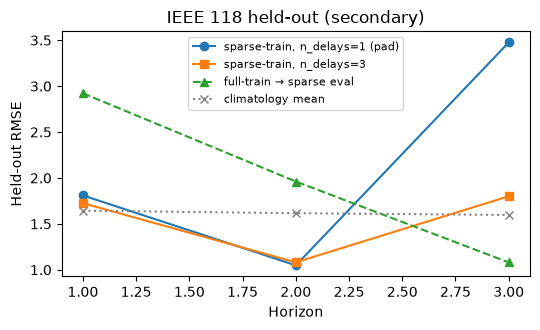

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 3.4))
ax.plot(e_c["horizons"], e_c["held_rmse"], marker="o", label="sparse-train, n_delays=1 (pad)")
ax.plot(
    e_d["horizons"],
    e_d["held_rmse"],
    marker="s",
    label=f"sparse-train, n_delays={k_ieee}",
)
ax.plot(
    e_f["horizons"],
    e_f["held_rmse"],
    marker="^",
    linestyle="--",
    label="full-train → sparse eval",
)
ax.plot(
    e_c["horizons"],
    e_c["mean_held_rmse"],
    marker="x",
    linestyle=":",
    color="gray",
    label="climatology mean",
)
ax.set_xlabel("Horizon")
ax.set_ylabel("Held-out RMSE")
ax.set_title("IEEE 118 held-out (secondary)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Takeaways

- **Empirical (Lorenz-96):** capacity-matched delay stacking stabilizes held-out
  multi-step RMSE while the pad control’s latent amplitude often explodes by
  $H=3$. That relative gap is the notebook’s decisive evidence.
- **Not claimed:** Takens embedding dimension, HAVOK forcing structure, or
  Hankel-DMD spectral convergence — those papers motivate delays; this demo
  composes delay channels with a GNN encoder.
- **Absolute skill:** models may sit above the in-sample climatology baseline;
  read relative pad vs delay curves.
- **Protocol:** library `fit` alone cannot supervise held-out nodes; use
  sparse→full training (as here) to test recovery.
- **Secondary panels:** drop-fraction and IEEE are stress checks only.
- **API:** size `in_channels = n_delays · F`. `predict` encodes observation
  history once (no decode→delay feedback by default).
